# AstroCLIP Teaching [Astroinfo2025]

This notebook walks through a compact AstroCLIP pipeline:

1. Load a manageable subset of the hosted `EiffL/AstroCLIP` dataset.
2. Train lightweight image and spectrum autoencoders entirely within the notebook.
3. Align both modalities with a CLIP loss.
4. Embed validation samples and explore the joint space.
5. Perform a simple downstream redshift regression.

Everything runs locally; no external scripts are required. Adjust hyper-parameters for longer or shorter runs.

## 0. Environment Prerequisites

Ensure you are running inside the `astroclip-teaching` (or mac equivalent) environment. Required packages: `datasets`, `torch`, `lightning`, `matplotlib`, `umap-learn`, `pandas`, `h5py`.

Set environment variables beforehand, e.g.:

```bash
export ASTROCLIP_ROOT=/path/to/astroclip_data   # adjust as needed
export HF_DATASETS_CACHE=/path/for/hf_cache     # optional, recommended for large downloads
```

The notebook below assumes the hosted dataset `EiffL/AstroCLIP` is accessible (or already cached).

In [ ]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

import torch
import lightning as L
from lightning.pytorch.callbacks import ModelCheckpoint

from datasets import load_dataset, load_from_disk, DatasetDict

import h5py
import umap

from astroclip.data.datamodule import AstroClipCollator

from teaching_scripts.data_utils import (
    load_astroclip_dataset,
    build_image_dataloader,
    build_spectrum_dataloader,
    build_multimodal_dataloader,
)
from teaching_scripts.models import (
    ImageAutoencoder,
    SpectrumAutoencoder,
    SmallCLIPModel,
)

os.environ["ASTROCLIP_ROOT"] = "/pbs/home/a/astroinfo08/astroinfo2025/data/AstroCLIP_data"
ASTROCLIP_ROOT = Path(os.environ.get('ASTROCLIP_ROOT')).resolve()
ASTROCLIP_ROOT.mkdir(parents=True, exist_ok=True)
DATASET_PATH = ASTROCLIP_ROOT
print(f"ASTROCLIP_ROOT: {ASTROCLIP_ROOT}")
print(f"Dataset path:  {DATASET_PATH}")

device = (
    torch.device("mps")
    if torch.backends.mps.is_available()
    else torch.device("cuda") if torch.cuda.is_available()
    else torch.device("cpu")
)
print("Using device:", device)



/Users/marchuertascompany/soft/miniforge3/envs/astroclip-mac/lib/python3.10/site-packages/lightning/fabric/__init__.py:41: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
/Users/marchuertascompany/soft/miniforge3/envs/astroclip-mac/lib/python3.10/site-packages/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/Users/marchuertascompany/soft/miniforge3/envs/astroclip-mac/lib/python3.10/site-packages/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/Users/marchuertascompany/soft/miniforge3/envs/astroclip-mac/lib/python3.10/site-packages/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is no

ASTROCLIP_ROOT: /Users/marchuertascompany/Documents/teaching/2025_astroinfo/data
Dataset path:  /Users/marchuertascompany/Documents/teaching/2025_astroinfo/data
Using device: mps


> 🧭 **Session bootstrap**
> - 🧰 Import core analytics libraries, Lightning utilities, and our helper modules from `teaching_scripts`.
> - 📁 Set `ASTROCLIP_ROOT` via an environment variable so everyone writes to the same workspace; create the folder if it is missing.
> - ⚙️ Detect the best accelerator (MPS/GPU/CPU) and store it in `device` for all subsequent `.to(device)` calls.


### Load Subset

Provide the path to a dataset prepared with `teaching_scripts/prepare_dataset.py` or `load_dataset(...).save_to_disk(...)`. Set `DATASET_PATH` accordingly.

In [ ]:
# Adjust this path to the existing subset
DATASET_PATH = ASTROCLIP_ROOT / "astroclip_subset_tiny" 

if not DATASET_PATH.exists():
    raise FileNotFoundError(f"{DATASET_PATH} not found. Prepare the subset first.")

ds = load_from_disk(DATASET_PATH)
print(ds)
display({split: len(ds[split]) for split in ds})

DatasetDict({
    train: Dataset({
        features: ['image', 'spectrum', 'redshift', 'targetid'],
        num_rows: 1024
    })
    test: Dataset({
        features: ['image', 'spectrum', 'redshift', 'targetid'],
        num_rows: 256
    })
})


{'train': 1024, 'test': 256}

> 📦 **Load a prepared subset**
> - 🗂️ Point `DATASET_PATH` to the tiny HuggingFace subset we staged beforehand.
> - 🚨 Fail fast with a helpful message if the path is missing.
> - 📊 Use `load_from_disk` and display the split sizes so the class sees how small the teaching dataset is.


### Inspect Sample

Visualise a few image/spectrum pairs to verify data integrity.

Image batch shape: torch.Size([4, 3, 144, 144])
Raw spectrum shape example: (7781, 1)
Flattened spectra shape: (4, 7781)


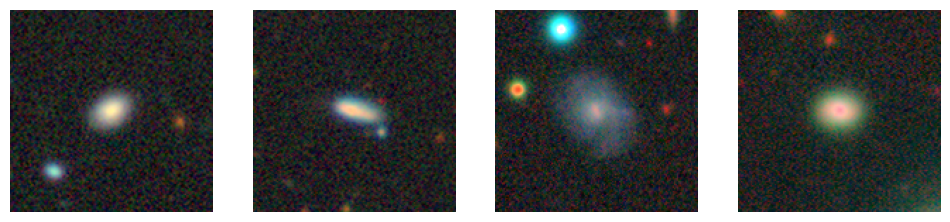

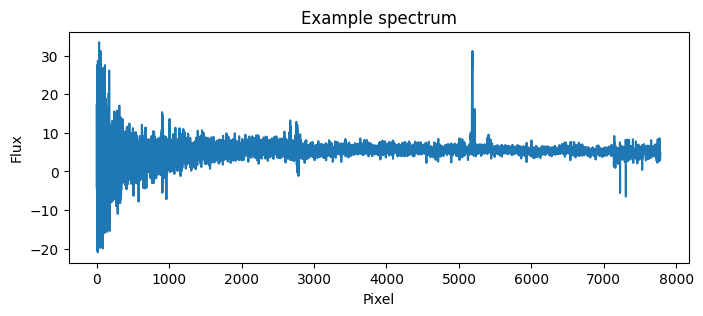

In [3]:
collator = AstroClipCollator(center_crop=144)

samples = []
for i in range(4):
    item = dict(ds['train'][i])
    item['image'] = np.asarray(item['image'])
    item['spectrum'] = np.asarray(item['spectrum'])
    samples.append(item)

batch = collator(samples)
images = batch['image']
spectra_raw = [np.asarray(s) for s in batch['spectrum']]
print('Image batch shape:', images.shape)
print('Raw spectrum shape example:', spectra_raw[0].shape)

spectra = np.stack([spec.reshape(-1) for spec in spectra_raw])
print('Flattened spectra shape:', spectra.shape)

fig, axes = plt.subplots(1, 4, figsize=(12, 4))
for ax, img in zip(axes, images):
    ax.imshow(img.permute(1, 2, 0).numpy())
    ax.axis('off')
plt.show()

plt.figure(figsize=(8, 3))
plt.plot(spectra[0])
plt.title('Example spectrum')
plt.xlabel('Pixel')
plt.ylabel('Flux')
plt.show()


> 🔍 **Peek at raw samples**
> - 🧮 Convert each record into NumPy arrays—streaming datasets sometimes return plain lists.
> - 🧪 Run `AstroClipCollator` to mimic the training-time preprocessing (RGB conversion + center crop).
> - 🖼️ Plot a grid of images and the first spectrum so students can visually confirm shapes and ranges.


In [ ]:
from pathlib import Path

def latest_version(log_dir: Path, run_name: str) -> Path:
    run_dir = log_dir / run_name
    candidates = sorted(run_dir.glob("version_*"), key=lambda p: p.stat().st_mtime)
    if not candidates:
        raise FileNotFoundError(f"No versions found under {run_dir}")
    return candidates[-1]

> 🗃️ **Helper: latest logger version**
> - 📂 Scan the Lightning log directory for folders named `version_*`.
> - 🔁 Return the most recent one (sorted by modification time) so we can reuse metrics when we skip training.
> - 🧩 This utility keeps the notebook in sync whether we train live or reload checkpoints.


## 1. Train Image Autoencoder

Use a lightweight convolutional autoencoder to encode 144×144 RGB crops. Training is intentionally short; increase `max_epochs` or model size for better reconstructions.

In [ ]:
from lightning.pytorch.loggers import CSVLogger

LOAD_IMAGE_CKPT = True
image_ckpt_path = ASTROCLIP_ROOT / 'models/image_autoencoder_notebook.ckpt'
image_logger = CSVLogger(save_dir=str(ASTROCLIP_ROOT / 'logs'), name='image_autoencoder_notebook')
image_train_loader = build_image_dataloader(ds['train'], batch_size=128, shuffle=True, num_workers=0)
image_val_loader = build_image_dataloader(ds['test'], batch_size=128, shuffle=False, num_workers=0)

if LOAD_IMAGE_CKPT and image_ckpt_path.exists():
    image_model = ImageAutoencoder.load_from_checkpoint(image_ckpt_path)
    log_root = ASTROCLIP_ROOT / "logs"
    image_version_dir = latest_version(log_root, "image_autoencoder_notebook")
    existing_version = image_verson_dir  # or 0; Lightning accepts either
    image_logger = CSVLogger(
    save_dir=str(ASTROCLIP_ROOT / "logs"),
    name="image_autoencoder_notebook",
    version=existing_version,
)
    print('Loaded pretrained model from ', image_ckpt_path)
else:
    image_model = ImageAutoencoder(embed_dim=256)
    checkpoint_img = ModelCheckpoint(dirpath=ASTROCLIP_ROOT, filename='image_autoencoder_notebook', save_last=True, save_top_k=1)
    trainer_img = L.Trainer(accelerator='auto', devices='auto', max_epochs=8,
                            log_every_n_steps=25, callbacks=[checkpoint_img], logger=image_logger)
    trainer_img.fit(image_model, image_train_loader, image_val_loader)
    trainer_img.save_checkpoint(image_ckpt_path)

Loaded pretrained model from  /Users/marchuertascompany/Documents/teaching/2025_astroinfo/data/image_autoencoder_notebook.ckpt


> 🧠 **Image autoencoder – train or load**
> - 🎚️ `LOAD_IMAGE_CKPT` toggles between reusing a pre-trained checkpoint and running a fresh 8-epoch fit.
> - 📓 When loading, we reconnect the `CSVLogger` to the latest version directory so later plots find `metrics.csv`.
> - 💾 Fresh training still uses Lightning with checkpointing, keeping artefacts under `models/` for future runs.


/Users/marchuertascompany/soft/miniforge3/envs/astroclip-mac/lib/python3.10/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


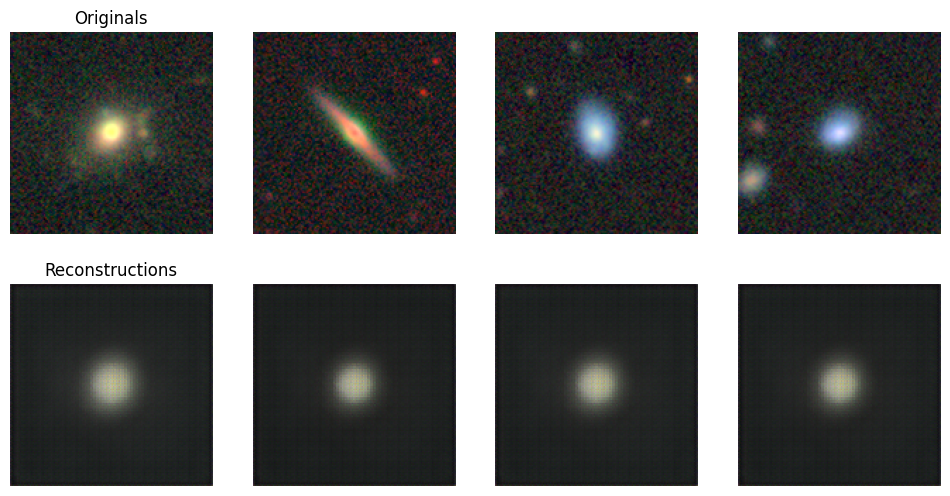

In [45]:
# Visualise image reconstruction
image_model.eval()
with torch.no_grad():
    batch_imgs = next(iter(image_val_loader))
    recon_imgs = image_model(batch_imgs.to(image_model.device)).cpu()

fig, axes = plt.subplots(2, min(4, len(batch_imgs)), figsize=(12, 6))
for i in range(min(4, len(batch_imgs))):
    axes[0, i].imshow(batch_imgs[i].permute(1, 2, 0).numpy())
    axes[0, i].axis('off')
    axes[1, i].imshow(recon_imgs[i].permute(1, 2, 0).numpy())
    axes[1, i].axis('off')
axes[0,0].set_title('Originals')
axes[1,0].set_title('Reconstructions')
plt.show()


> 🖼️ **Check reconstructions**
> - 📤 Switch the autoencoder to eval mode and sample a validation batch.
> - 🪞 Show originals vs. reconstructions in a 2×N panel so the audience can gauge what details are preserved.


In [ ]:
history_img = trainer_img.logged_metrics
print("Final logged metrics:", history_img)

train_hist_img = trainer_img.callback_metrics.get('train_loss')
val_hist_img = trainer_img.callback_metrics.get('val_loss')

> 📈 **Inspect logged metrics**
> - 🧾 `trainer_img.logged_metrics` exposes Lightning’s final values (great for a quick sanity check).
> - 🔍 Store them so we can reference the numbers when discussing convergence.


In [ ]:
metrics_img = trainer_img.logger.experiment.metrics if hasattr(trainer_img.logger, 'experiment') else []
if metrics_img:
    # When using the default logger the metrics list may be empty; fallback to manual history if available
    print(metrics_img[:3])

> 🧪 **Logger fallback**
> - ✅ Some loggers lazily expose `experiment.metrics`; grab a preview when it exists.
> - 🛟 This keeps the notebook resilient even if the logger backend changes.


Plot the loss curve from the trainer logs.

In [ ]:
import pandas as pd
from pathlib import Path

metrics_path_img = Path(image_logger.log_dir) / 'metrics.csv'
if metrics_path_img.exists():
    df_img = pd.read_csv(metrics_path_img)
else:
    df_img = pd.DataFrame()

if not df_img.empty:
    plt.figure(figsize=(6, 4))
    if 'train_loss' in df_img.columns:
        plt.plot(df_img['epoch'], df_img['train_loss'], label='train_loss')
    if 'val_loss' in df_img.columns:
        plt.plot(df_img['epoch'], df_img['val_loss'], label='val_loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Image AE loss curve')
    plt.legend()
    plt.show()
else:
    print('No metrics recorded for plotting. Check logger output.')

> 📉 **Plot the image AE loss**
> - 📁 Load `metrics.csv` from the resolved logger directory.
> - 📊 Plot train vs validation curves to talk about under/overfitting behaviour.
> - 📝 Encourage students to read legends and axes when interpreting Lightning logs.


## 2. Train Spectrum Autoencoder

A simple fully-connected autoencoder for the 1D spectra.

In [ ]:
from lightning.pytorch.loggers import CSVLogger as CSVLoggerSpec

LOAD_SPECTRUM_CKPT = True
spectrum_ckpt_path = ASTROCLIP_ROOT / 'models/spectrum_autoencoder_notebook.ckpt'
spectrum_logger = CSVLoggerSpec(save_dir=str(ASTROCLIP_ROOT / 'logs'), name='spectrum_autoencoder_notebook')
spectrum_train_loader = build_spectrum_dataloader(ds['train'], batch_size=256, shuffle=True, num_workers=0)
spectrum_val_loader = build_spectrum_dataloader(ds['test'], batch_size=256, shuffle=False, num_workers=0)

sample_spec = ds['train'][0]['spectrum']
input_dim = int(np.prod(np.asarray(sample_spec).shape))

if LOAD_SPECTRUM_CKPT and spectrum_ckpt_path.exists():
    #spectrum_model = SpectrumAutoencoder.load_from_checkpoint(spectrum_ckpt_path)
    spectrum_model = SpectrumTransformer(input_dim=7781, patch_size=16, embed_dim=256)
    print('Loaded pretrained model from ', spectrum_ckpt_path)
else:
    spectrum_model = SpectrumAutoencoder(input_dim=input_dim, embed_dim=256)
    checkpoint_spec = ModelCheckpoint(dirpath=ASTROCLIP_ROOT, filename='spectrum_autoencoder_notebook', save_last=True, save_top_k=1)
    trainer_spec = L.Trainer(accelerator='auto', devices='auto', max_epochs=12,
                             log_every_n_steps=25, callbacks=[checkpoint_spec], logger=spectrum_logger)
    trainer_spec.fit(spectrum_model, spectrum_train_loader, spectrum_val_loader)
    trainer_spec.save_checkpoint(spectrum_ckpt_path)

Loaded pretrained model from  /Users/marchuertascompany/Documents/teaching/2025_astroinfo/data/spectrum_autoencoder_notebook.ckpt


> 🌈 **Spectrum autoencoder toggle**
> - 🔄 Mirrors the image block but for flattened spectra.
> - 🎚️ `LOAD_SPECTRUM_CKPT` controls whether we retrain or reuse existing weights.
> - 🧠 Highlights that spectra enter as 1D vectors before the MLP autoencoder.


/Users/marchuertascompany/soft/miniforge3/envs/astroclip-mac/lib/python3.10/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


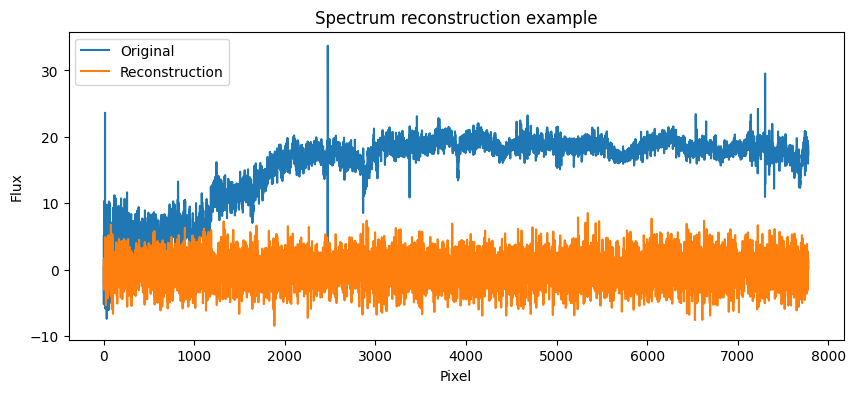

In [8]:
# Visualise spectrum reconstruction
spectrum_model.eval()
with torch.no_grad():
    batch_spec = next(iter(spectrum_val_loader))
    recon_spec = spectrum_model(batch_spec.to(spectrum_model.device)).cpu()

plt.figure(figsize=(10, 4))
plt.plot(batch_spec[0].numpy(), label='Original')
plt.plot(recon_spec[0].numpy(), label='Reconstruction')
plt.title('Spectrum reconstruction example')
plt.xlabel('Pixel')
plt.ylabel('Flux')
plt.legend()
plt.show()


> 📡 **Spectrum reconstruction check**
> - 📤 Eval mode, pull a validation mini-batch.
> - 📈 Plot original vs reconstructed spectrum to discuss which wavelength ranges are hardest to recover.


In [9]:
metrics_path_spec = Path(spectrum_logger.log_dir) / 'metrics.csv'
if metrics_path_spec.exists():
    df_spec = pd.read_csv(metrics_path_spec)
else:
    df_spec = pd.DataFrame()

if not df_spec.empty:
    plt.figure(figsize=(6, 4))
    if 'train_loss' in df_spec.columns:
        plt.plot(df_spec['epoch'], df_spec['train_loss'], label='train_loss')
    if 'val_loss' in df_spec.columns:
        plt.plot(df_spec['epoch'], df_spec['val_loss'], label='val_loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Spectrum AE loss curve')
    plt.legend()
    plt.show()
else:
    print('No metrics recorded for plotting. Check logger output.')

No metrics recorded for plotting. Check logger output.


> 📉 **Plot spectrum loss**
> - 📁 Read the spectrum logger’s `metrics.csv`.
> - 📊 Draw the curves just like before—repetition helps cement the workflow.


## 3. CLIP Alignment

Load the two autoencoders and train the CLIP objective for a few epochs.

In [12]:
from lightning.pytorch.loggers import CSVLogger as CSVLoggerClip


LOAD_CLIP_CKPT = True
clip_ckpt_path = ASTROCLIP_ROOT / 'clip_alignment_notebook.ckpt'
clip_logger = CSVLoggerClip(save_dir=str(ASTROCLIP_ROOT / 'logs'), name='clip_alignment_notebook')
clip_train_loader = build_multimodal_dataloader(ds['train'], batch_size=256, shuffle=True, num_workers=0)
clip_val_loader = build_multimodal_dataloader(ds['test'], batch_size=256, shuffle=False, num_workers=0)

image_encoder = ImageAutoencoder.load_from_checkpoint(image_ckpt_path)
spectrum_encoder = SpectrumAutoencoder.load_from_checkpoint(spectrum_ckpt_path)

if LOAD_CLIP_CKPT and clip_ckpt_path.exists():
    clip_model = SmallCLIPModel.load_from_checkpoint(
        clip_ckpt_path,
        image_encoder=image_encoder,
        spectrum_encoder=spectrum_encoder,
    )
    print("Pretrained model loaded from ", clip_ckpt_path)
else:
    
    clip_model = SmallCLIPModel(
        image_encoder=image_encoder,
        spectrum_encoder=spectrum_encoder,
        projection_dim=256,
        lr=5e-4,
        temperature=0.1,
        finetune_encoders=False,
    )
    checkpoint_clip = ModelCheckpoint(dirpath=ASTROCLIP_ROOT, filename='clip_alignment_notebook', save_last=True, save_top_k=1)
    trainer_clip = L.Trainer(accelerator='auto', devices='auto', max_epochs=10,
                             log_every_n_steps=25, callbacks=[checkpoint_clip], logger=clip_logger)
    trainer_clip.fit(clip_model, clip_train_loader, clip_val_loader)
    trainer_clip.save_checkpoint(clip_ckpt_path)

Pretrained model loaded from  /Users/marchuertascompany/Documents/teaching/2025_astroinfo/data/clip_alignment_notebook.ckpt


> 🔗 **CLIP alignment block**
> - ♻️ Load the image & spectrum autoencoder checkpoints into the CLIP head.
> - 🎚️ `LOAD_CLIP_CKPT` lets us reuse a pre-trained alignment or run a fresh Lightning fit.
> - 🧱 When training, we keep the same checkpoint/logging pattern for consistency.


In [13]:
metrics_path_clip = Path(clip_logger.log_dir) / 'metrics.csv'
if metrics_path_clip.exists():
    df_clip = pd.read_csv(metrics_path_clip)
else:
    df_clip = pd.DataFrame()

if not df_clip.empty:
    fig, ax = plt.subplots(figsize=(6, 4))
    if 'train_loss' in df_clip.columns:
        ax.plot(df_clip['epoch'], df_clip['train_loss'], label='train_loss')
    if 'val_loss' in df_clip.columns:
        ax.plot(df_clip['epoch'], df_clip['val_loss'], label='val_loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('CLIP alignment loss curve')
    ax.legend(loc='upper left')
    if 'logit_scale' in df_clip.columns:
        ax2 = ax.twinx()
        ax2.plot(df_clip['epoch'], df_clip['logit_scale'], color='tab:green', linestyle='--', label='logit_scale')
        ax2.set_ylabel('Logit scale')
        ax2.legend(loc='lower right')
    plt.show()
else:
    print('No metrics recorded for plotting. Check logger output.')

No metrics recorded for plotting. Check logger output.


> 📊 **CLIP training curves**
> - 📁 Fetch `metrics.csv` for the CLIP run and plot train vs validation loss.
> - 🧮 Overlay `logit_scale` on a secondary axis to spark a discussion about temperature learning.


## 4. Embed Validation Split

Generate embeddings for the test split and store them for later use.

In [15]:
clip_model.eval()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
clip_model.to(device)

val_loader = build_multimodal_dataloader(ds['test'], batch_size=256, shuffle=False, num_workers=0)

image_embeddings = []
spectrum_embeddings = []
redshifts = []
targetids = []

with torch.no_grad():
    for batch in val_loader:
        images = batch['image'].to(device)
        spectra = batch['spectrum'].to(device)
        img_emb, sp_emb = clip_model(images, spectra)
        image_embeddings.append(img_emb.cpu().numpy())
        spectrum_embeddings.append(sp_emb.cpu().numpy())
        if 'redshift' in batch:
            redshifts.append(batch['redshift'].numpy())
        if 'targetid' in batch:
            targetids.append(batch['targetid'].numpy())

image_embeddings = np.concatenate(image_embeddings, axis=0)
spectrum_embeddings = np.concatenate(spectrum_embeddings, axis=0)
redshift = np.concatenate(redshifts, axis=0) if redshifts else None
targetid = np.concatenate(targetids, axis=0) if targetids else None

print(image_embeddings.shape, spectrum_embeddings.shape)


(256, 256) (256, 256)


> 📥 **Embed the validation split**
> - 🧊 Freeze the CLIP model (`eval()`), iterate over the loader, and collect image & spectrum embeddings.
> - 🧾 Store optional metadata (`redshift`, `targetid`) so downstream notebooks can run regressions immediately.
> - 🔍 Print the embedding shapes to reassure everyone the batching worked.


### UMAP Projection

Visualise the joint embedding space.

/Users/marchuertascompany/soft/miniforge3/envs/astroclip-mac/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


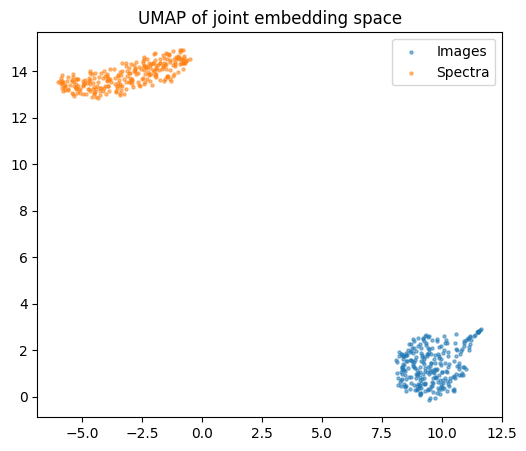

In [16]:
reducer = umap.UMAP(random_state=42)
joint = reducer.fit_transform(np.concatenate([image_embeddings, spectrum_embeddings], axis=0))
labels = np.concatenate([np.zeros(len(image_embeddings)), np.ones(len(spectrum_embeddings))])

plt.figure(figsize=(6, 5))
plt.scatter(joint[labels == 0, 0], joint[labels == 0, 1], s=5, alpha=0.5, label='Images')
plt.scatter(joint[labels == 1, 0], joint[labels == 1, 1], s=5, alpha=0.5, label='Spectra')
plt.legend()
plt.title('UMAP of joint embedding space')
plt.show()

> 🗺️ **UMAP tour**
> - ✨ Concatenate image and spectrum embeddings, project them with UMAP, and colour by modality.
> - 🧠 Great visual anchor to explain what “shared latent space” means in practice.


## 5. Downstream Redshift Regression

Train a tiny MLP on the image embeddings.

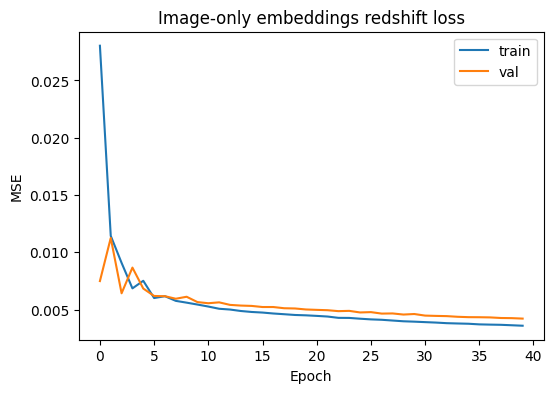

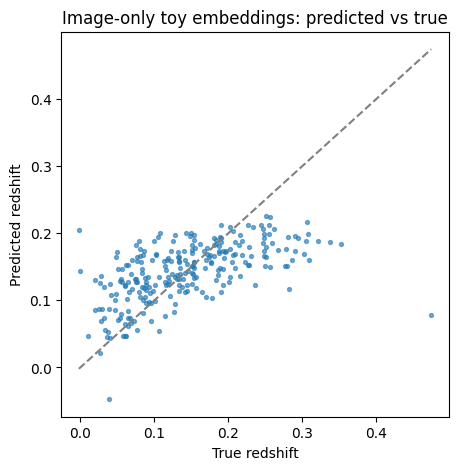

In [22]:
from torch.utils.data import DataLoader, TensorDataset

# Embed train/test splits using only image encodings from the toy CLIP model
clip_model.eval()

def embed_images(loader):
    embeds, targets = [], []
    with torch.no_grad():
        for batch in loader:
            imgs = batch["image"].to(device)
            emb = clip_model.encode_image(imgs)
            embeds.append(emb.cpu().numpy())
            targets.append(batch["redshift"].numpy())
    return np.concatenate(embeds, axis=0), np.concatenate(targets, axis=0)

train_loader = build_multimodal_dataloader(ds["train"], batch_size=256, shuffle=False, num_workers=0)
val_loader   = build_multimodal_dataloader(ds["test"],  batch_size=256, shuffle=False, num_workers=0)

train_emb, train_z = embed_images(train_loader)
val_emb,   val_z   = embed_images(val_loader)

train_ds = TensorDataset(torch.from_numpy(train_emb).float(), torch.from_numpy(train_z).float())
val_ds   = TensorDataset(torch.from_numpy(val_emb).float(),   torch.from_numpy(val_z).float())
train_dl = DataLoader(train_ds, batch_size=256, shuffle=True)
val_dl   = DataLoader(val_ds, batch_size=256, shuffle=False)

dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class MLP(torch.nn.Module):
    def __init__(self, input_dim, hidden=256):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(input_dim, hidden),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden, hidden // 2),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden // 2, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

model_img = MLP(train_emb.shape[1]).to(dev)
criterion = torch.nn.MSELoss()
optimizer = torch.optim.AdamW(model_img.parameters(), lr=3e-4, weight_decay=1e-5)

train_losses_img, val_losses_img = [], []
for epoch in range(40):
    model_img.train()
    running = 0.0
    for batch_x, batch_y in train_dl:
        batch_x, batch_y = batch_x.to(dev), batch_y.to(dev)
        optimizer.zero_grad(set_to_none=True)
        preds = model_img(batch_x)
        loss = criterion(preds, batch_y)
        loss.backward()
        optimizer.step()
        running += loss.item() * batch_x.size(0)
    train_loss = running / len(train_dl.dataset)

    model_img.eval()
    running = 0.0
    with torch.no_grad():
        for batch_x, batch_y in val_dl:
            batch_x, batch_y = batch_x.to(dev), batch_y.to(dev)
            preds = model_img(batch_x)
            loss = criterion(preds, batch_y)
            running += loss.item() * batch_x.size(0)
    val_loss = running / len(val_dl.dataset)
    train_losses_img.append(train_loss)
    val_losses_img.append(val_loss)

plt.figure(figsize=(6, 4))
plt.plot(train_losses_img, label="train")
plt.plot(val_losses_img, label="val")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Image-only embeddings redshift loss")
plt.legend()
plt.show()

model_img.eval()
preds_img = []
with torch.no_grad():
    for batch_x, _ in val_dl:
        preds_img.extend(model_img(batch_x.to(dev)).cpu().numpy())
preds_img = np.array(preds_img)

plt.figure(figsize=(5, 5))
plt.scatter(val_z[: len(preds_img)], preds_img, s=8, alpha=0.6)
lims = [val_z.min(), val_z.max()]
plt.plot(lims, lims, "--", color="gray")
plt.xlabel("True redshift")
plt.ylabel("Predicted redshift")
plt.title("Image-only toy embeddings: predicted vs true")
plt.show()


> 🧮 **Regression on toy image embeddings**
> - 🧱 Build simple `TensorDataset` loaders from the image-only embeddings.
> - 🧠 Train a tiny MLP regressor (40 epochs) to predict redshift—fast but perfect for demonstrating evaluation.
> - 📉 Plot the loss curve to compare against the CLIP joint model.


## 7. Image-Only CNN Baseline

To gauge the benefit of multimodal training, we train a small CNN directly on the RGB images and compare its redshift predictions with the CLIP-based approach.

In [ ]:
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

class ImageRedshiftDataset(Dataset):
    def __init__(self, hf_dataset):
        self.dataset = hf_dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        record = dict(self.dataset[idx])
        image = np.asarray(record["image"], dtype=np.float32)           # H x W x C
        image = torch.from_numpy(image).permute(2, 0, 1)                # -> C x H x W
        redshift = torch.tensor(float(record["redshift"]), dtype=torch.float32)
        return image, redshift

cnn_train_ds = ImageRedshiftDataset(ds["train"])
cnn_val_ds   = ImageRedshiftDataset(ds["test"])
cnn_train_loader = DataLoader(cnn_train_ds, batch_size=128, shuffle=True,  num_workers=0)
cnn_val_loader   = DataLoader(cnn_val_ds,   batch_size=128, shuffle=False, num_workers=0)

class ImageCNN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Conv2d(3, 32, kernel_size=5, stride=2, padding=2),
            torch.nn.ReLU(),
            torch.nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            torch.nn.BatchNorm2d(64),
            torch.nn.ReLU(),
            torch.nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            torch.nn.BatchNorm2d(128),
            torch.nn.ReLU(),
            torch.nn.AdaptiveAvgPool2d((1, 1)),  # works on MPS
        )
        self.fc = torch.nn.Sequential(
            torch.nn.Flatten(),
            torch.nn.Linear(128, 256),
            torch.nn.ReLU(),
            torch.nn.Linear(256, 1),
        )

    def forward(self, x):
        features = self.net(x)
        return self.fc(features).squeeze(-1)


cnn_model = ImageCNN().to(device)
criterion_reg = torch.nn.MSELoss()
optimizer_cnn = torch.optim.AdamW(cnn_model.parameters(), lr=1e-3, weight_decay=1e-4)

epochs = 5
cnn_train_losses, cnn_val_losses = [], []
for epoch in range(epochs):
    cnn_model.train()
    running = 0.0
    for imgs, zs in tqdm(cnn_train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False):
        imgs, zs = imgs.to(device), zs.to(device)
        optimizer_cnn.zero_grad(set_to_none=True)
        preds = cnn_model(imgs)
        loss = criterion_reg(preds, zs)
        loss.backward()
        optimizer_cnn.step()
        running += loss.item() * imgs.size(0)
    train_loss = running / len(cnn_train_loader.dataset)

    cnn_model.eval()
    running = 0.0
    with torch.no_grad():
        for imgs, zs in cnn_val_loader:
            imgs, zs = imgs.to(device), zs.to(device)
            preds = cnn_model(imgs)
            loss = criterion_reg(preds, zs)
            running += loss.item() * imgs.size(0)
    val_loss = running / len(cnn_val_loader.dataset)

    cnn_train_losses.append(train_loss)
    cnn_val_losses.append(val_loss)
    tqdm.write(f"Epoch {epoch+1:02d}: train={train_loss:.4f}, val={val_loss:.4f}")

plt.figure(figsize=(6, 4))
plt.plot(cnn_train_losses, label="train")
plt.plot(cnn_val_losses, label="val")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Image-only CNN redshift loss")
plt.legend()
plt.show()

cnn_model.eval()
cnn_preds, cnn_truth = [], []
with torch.no_grad():
    for imgs, zs in cnn_val_loader:
        preds = cnn_model(imgs.to(device)).cpu().numpy()
        cnn_preds.append(preds)
        cnn_truth.append(zs.numpy())
cnn_preds  = np.concatenate(cnn_preds)
cnn_truth = np.concatenate(cnn_truth)

plt.figure(figsize=(5, 5))
plt.scatter(cnn_truth, cnn_preds, s=8, alpha=0.5)
lims = [cnn_truth.min(), cnn_truth.max()]
plt.plot(lims, lims, "--", color="gray")
plt.xlabel("True redshift")
plt.ylabel("Predicted redshift")
plt.title("Image-only CNN predictions")
plt.show()


Using device: mps


Epoch 1/5:   0%|          | 0/8 [00:00<?, ?it/s]

KeyboardInterrupt: 

> 🖼️ **Image-only CNN baseline**
> - 📦 Wrap the HF dataset in a `Dataset` that returns channel-first tensors.
> - 🧠 Train a compact CNN (conv → batch-norm → adaptive pool) directly on images; use `tqdm` so the class can follow progress.
> - 📉 Plot the train/val loss to compare with the embedding-based approach.


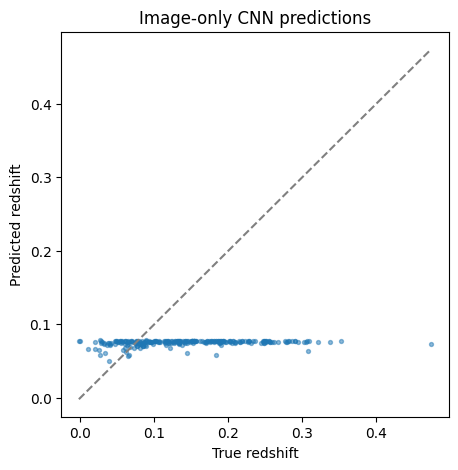

In [30]:
# Predicted vs true for the image-only CNN
cnn_model.eval()
cnn_preds, cnn_truth = [], []
with torch.no_grad():
    for imgs, zs in cnn_val_loader:
        preds = cnn_model(imgs.to(device)).cpu().numpy()
        cnn_preds.append(preds)
        cnn_truth.append(zs.numpy())
cnn_preds = np.concatenate(cnn_preds)
cnn_truth = np.concatenate(cnn_truth)

plt.figure(figsize=(5, 5))
plt.scatter(cnn_truth, cnn_preds, s=8, alpha=0.5)
lims = [cnn_truth.min(), cnn_truth.max()]
plt.plot(lims, lims, '--', color='gray')
plt.xlabel('True redshift')
plt.ylabel('Predicted redshift')
plt.title('Image-only CNN predictions')
plt.show()


> 🎯 **CNN predictions vs. truth**
> - 📍 Scatter plot of predicted vs. true redshift for the CNN baseline.
> - 🧭 Draw the diagonal to highlight bias/variance trade-offs.


## 8. Using the Official AstroCLIP Checkpoint

Load the published `astroclip.ckpt` checkpoint and run it over our dataset to obtain the reference image and spectrum embeddings.

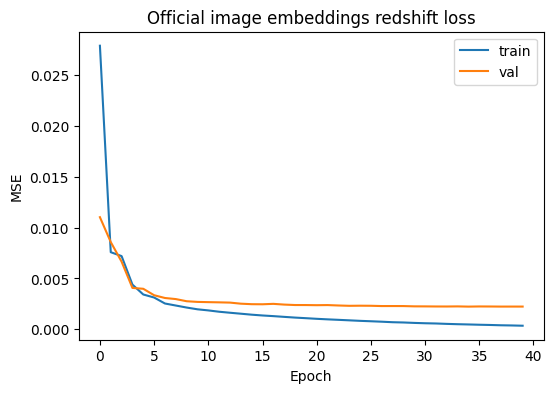

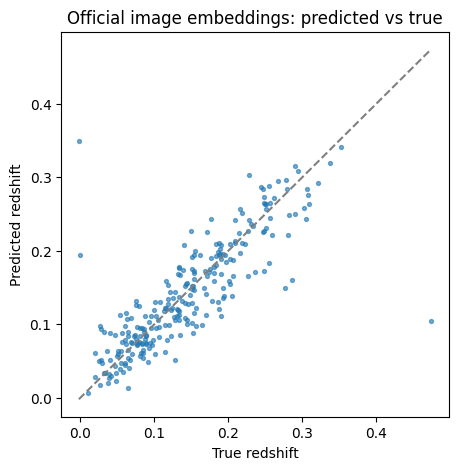

In [41]:
import h5py
from torch.utils.data import TensorDataset, DataLoader

# Adjust paths if you saved the files elsewhere
ROOT = Path("/Users/marchuertascompany/Documents/teaching/2025_astroinfo/data")
IMG_TRAIN_H5 = ROOT / "embeddings_image_train.h5"
IMG_TEST_H5  = ROOT / "embeddings_image_test.h5"

def load_split(path):
    with h5py.File(path, "r") as f:
        emb = f["image_embeddings"][:]
        z   = f["redshift"][:]
    return emb, z

train_emb, train_z = load_split(IMG_TRAIN_H5)
val_emb,   val_z   = load_split(IMG_TEST_H5)

train_ds = TensorDataset(torch.from_numpy(train_emb).float(), torch.from_numpy(train_z).float())
val_ds   = TensorDataset(torch.from_numpy(val_emb).float(),   torch.from_numpy(val_z).float())
train_dl = DataLoader(train_ds, batch_size=256, shuffle=True)
val_dl   = DataLoader(val_ds, batch_size=256, shuffle=False)

class MLP(torch.nn.Module):
    def __init__(self, input_dim, hidden=256):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(input_dim, hidden),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden, hidden // 2),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden // 2, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

official_model = MLP(train_emb.shape[1]).to(device)          # MLP already defined above
optimizer = torch.optim.AdamW(official_model.parameters(), lr=3e-4, weight_decay=1e-5)
criterion = torch.nn.MSELoss()

official_train_losses, official_val_losses = [], []
for epoch in range(40):
    official_model.train()
    running = 0.0
    for x_batch, y_batch in train_dl:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad(set_to_none=True)
        preds = official_model(x_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        running += loss.item() * x_batch.size(0)
    train_loss = running / len(train_dl.dataset)

    official_model.eval()
    running = 0.0
    with torch.no_grad():
        for x_batch, y_batch in val_dl:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            preds = official_model(x_batch)
            loss = criterion(preds, y_batch)
            running += loss.item() * x_batch.size(0)
    val_loss = running / len(val_dl.dataset)

    official_train_losses.append(train_loss)
    official_val_losses.append(val_loss)

plt.figure(figsize=(6, 4))
plt.plot(official_train_losses, label="train")
plt.plot(official_val_losses, label="val")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Official image embeddings redshift loss")
plt.legend()
plt.show()

official_model.eval()
official_preds = []
with torch.no_grad():
    for x_batch, _ in val_dl:
        official_preds.extend(official_model(x_batch.to(device)).cpu().numpy())
official_preds = np.array(official_preds)

plt.figure(figsize=(5, 5))
plt.scatter(val_z[: len(official_preds)], official_preds, s=8, alpha=0.6)
lims = [val_z.min(), val_z.max()]
plt.plot(lims, lims, "--", color="gray")
plt.xlabel("True redshift")
plt.ylabel("Predicted redshift")
plt.title("Official image embeddings: predicted vs true")
plt.show()


> 🏅 **Official AstroCLIP embeddings**
> - 📁 Load the precomputed HDF5 files for train/test image embeddings + redshift.
> - 🧠 Reuse the same MLP architecture to evaluate the “upper bound” performance students should compare against.
> - 📉 Plot the loss curves and predicted-vs-true scatter to wrap up the benchmarking story.
